## 📚 Module 09: Data Preprocessing & Feature Engineering — সম্পূর্ণ বাংলা গাইড

📌 1. Missing Values (অনুপস্থিত মান) — Titanic Dataset
🔸 বাস্তব উপমা: হাজিরা খাতা

মনে করো স্কুলের হাজিরা খাতায় কিছু ঘর খালি। যদি সেই খালি ঘরগুলো হিসাব না করি, উপস্থিতির হার ভুল আসবে। তাই আমাদের সিদ্ধান্ত নিতে হবে খালি ঘরগুলো নিয়ে কী করব।

Titanic dataset-এ:

### Age — numeric column এ missing values আছে
### Embarked — categorical column এ ২টি missing values আছে
### Cabin — এত বেশি missing যে বাদ দেওয়াই ভালো

আমরা করব:

Missing values পর্যবেক্ষণ
Age → Median দিয়ে পূরণ করব (কারণ skewed distribution)
Embarked → Mode দিয়ে পূরণ করব
Cabin → সম্পূর্ণ বাদ দেব

In [7]:
import pandas as pd
from Demos.win32cred_demo import target
from matplotlib.pyplot import title


titanic_path = pd.read_csv("Titanic-Dataset.csv")
df_titanic = titanic_path
df_titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [8]:
shape = df_titanic.shape
print("আউটপুট: (891, 12) — মানে ৮৯১ যাত্রী, ১২টি column।",shape)

আউটপুট: (891, 12) — মানে ৮৯১ যাত্রী, ১২টি column। (891, 12)


In [9]:
print("Unique values per column:")
df_titanic.nunique()

Unique values per column:


PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [10]:
print("Missing values per column:")
df_titanic.isnull().sum()

Missing values per column:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

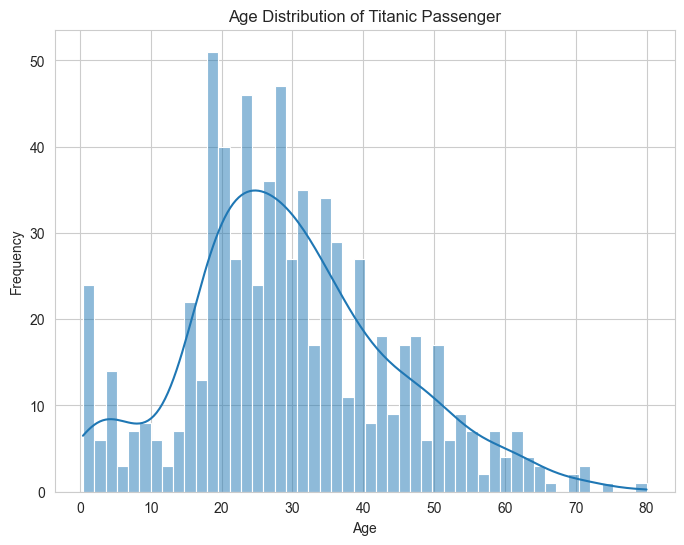

'\n"ব্যাখ্যা: Histogram দেখে বোঝা যাচ্ছে Age distribution right-skewed (ডানদিকে লেজ আছে)\nSkewed data-তে Median সঠিক central tendency\nMean ব্যবহার করলে outlier-দের কারণে বিকৃত হবে")##\n'

In [11]:
#💻 কোড ৫: Age Column-এর Distribution দেখা

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.histplot(df_titanic["Age"], kde=True, bins=50)
plt.title("Age Distribution of Titanic Passenger")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
"""
"ব্যাখ্যা: Histogram দেখে বোঝা যাচ্ছে Age distribution right-skewed (ডানদিকে লেজ আছে)
Skewed data-তে Median সঠিক central tendency
Mean ব্যবহার করলে outlier-দের কারণে বিকৃত হবে")##
"""

Distribution of Embarked Column:


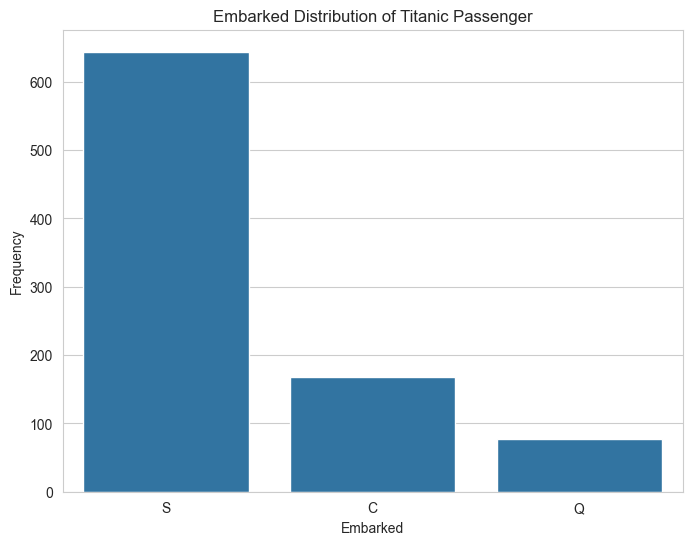

In [12]:
#💻 কোড ৬: Embarked Column-এর Distribution দেখা

print("Distribution of Embarked Column:")
plt.figure(figsize=(8,6))
sns.countplot(data=df_titanic, x="Embarked")
plt.title("Embarked Distribution of Titanic Passenger")
plt.xlabel("Embarked")
plt.ylabel("Frequency")
plt.show()

In [13]:
print("Before drop:", df_titanic.columns)


Before drop: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [14]:
#💻 কোড ৭: Missing Values পূরণ করা

# 1. Numeric missing values → Age কে Median দিয়ে পূরণ
age_median = df_titanic["Age"].median()
df_titanic["Age"] = df_titanic["Age"].fillna(age_median)

# 2. Categorical missing values → Embarked কে Mode দিয়ে পূরণ
embarked_mode = df_titanic["Embarked"].mode()[0]
df_titanic["Embarked"] = df_titanic["Embarked"].fillna(embarked_mode)


# 3. Cabin বাদ দেওয়া (বেশিরভাগই missing)
df_titanic = df_titanic.drop(columns=["Cabin"], errors="ignore")

In [15]:
print("Missing values after handling:")
df_titanic.isnull().sum()

Missing values after handling:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# 📌 2. Encoding Categorical Variables — Heart Dataset
🔸 বাস্তব উপমা: ক্যান্টিনের টোকেন সিস্টেম

#### মনে করো ক্যান্টিনে আইটেম আছে: তেহারি, চাউমিন, বিরিয়ানি। বিলিং মেশিন স্ট্রিং বোঝে না — শুধু সংখ্যা বোঝে। কিন্তু তেহারি=1, চাউমিন=2, বিরিয়ানি=3 করলে ভুল হবে — কারণ এতে বোঝায় বিরিয়ানি > চাউমিন > তেহারি, যেটা সত্য না!

## দুটি পদ্ধতি:

### Label Encoding → Binary (দুটি মাত্র category) এর জন্য, যেমন Sex (M/F), ExerciseAngina (Y/N)
### OneHot Encoding → Nominal (কোনো ক্রম নেই) এর জন্য, যেমন ChestPainType, RestingECG, ST_Slope

In [16]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

heart_path = pd.read_csv("heart.csv")
df_heart = heart_path
print("First 10 rows of Heart dataset:")
df_heart.head(20)



First 10 rows of Heart dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [17]:
print("\n=== Data Types of All Columns ===")
print(df_heart.dtypes)


=== Data Types of All Columns ===
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object



Sex distribution:
Sex
M    725
F    193
Name: count, dtype: int64


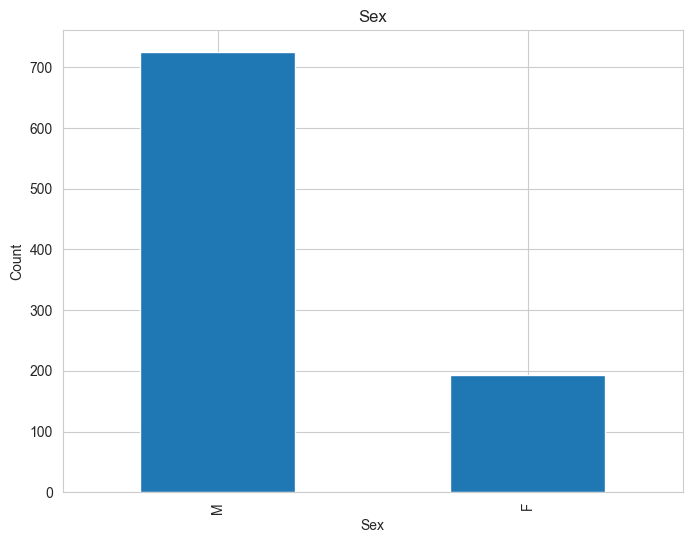


ChestPainType distribution:
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


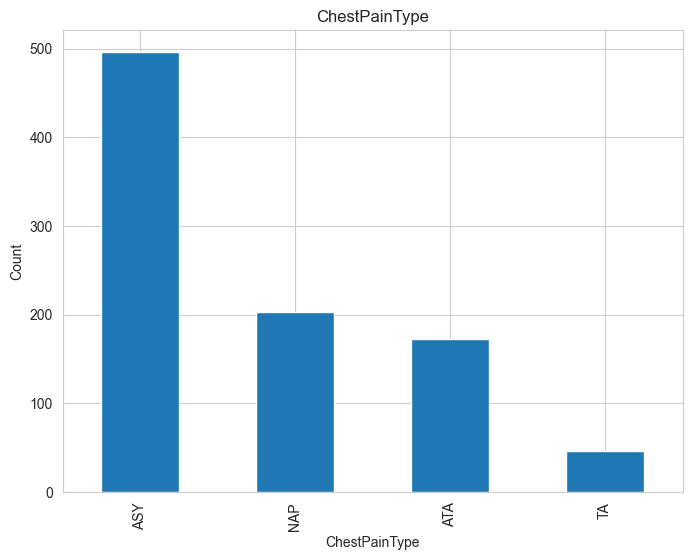


RestingECG distribution:
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


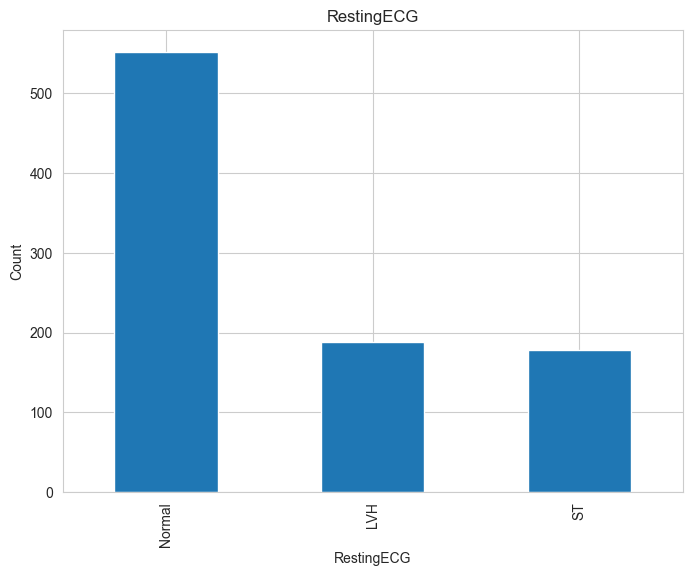


ExerciseAngina distribution:
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


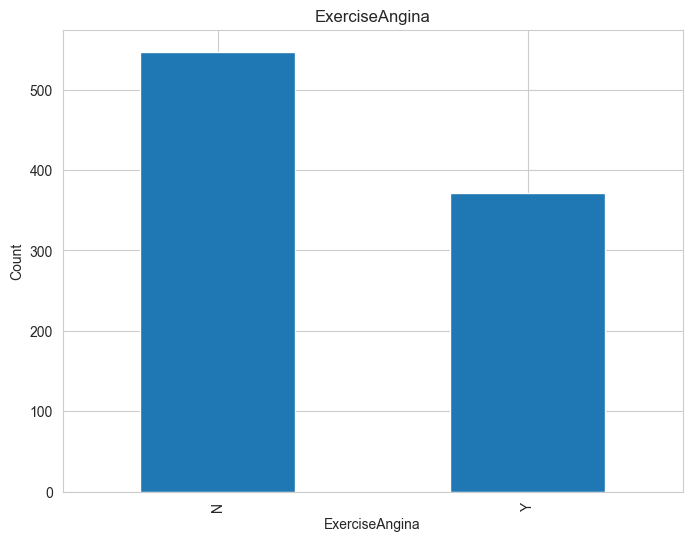


ST_Slope distribution:
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


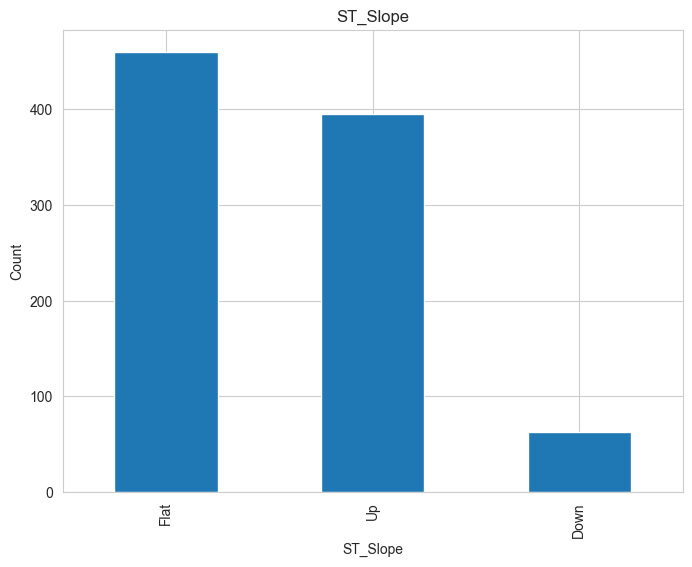

In [18]:
#💻 কোড ১০: Categorical Columns Explore করা

categorical_cols = ["Sex", "ChestPainType", "RestingECG",
                    "ExerciseAngina", "ST_Slope"]

for c in categorical_cols:
    counts = df_heart[c].value_counts()

    print(f"\n{c} distribution:")
    print(counts)

    counts.plot(kind="bar", figsize=(8,6), title=c)
    plt.ylabel("Count")
    plt.show()


In [19]:
# 💻 কোড ১১: Label Encoding (Binary Columns)

# Binary categorical columns → Label Encoding

from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
df_heart["Sex"] = le_sex.fit_transform(df_heart["Sex"])

le_angina = LabelEncoder()
df_heart["ExerciseAngina"] = le_angina.fit_transform(df_heart["ExerciseAngina"])



In [20]:
#💻 কোড ১২: Label Encoding-এর পর দেখা

df_heart.head(20)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0
5,39,1,NAP,120,339,0,Normal,170,0,0.0,Up,0
6,45,0,ATA,130,237,0,Normal,170,0,0.0,Up,0
7,54,1,ATA,110,208,0,Normal,142,0,0.0,Up,0
8,37,1,ASY,140,207,0,Normal,130,1,1.5,Flat,1
9,48,0,ATA,120,284,0,Normal,120,0,0.0,Up,0


In [21]:
#💻 কোড ১৩: OneHot Encoding (Nominal Columns)

cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]

df_heart_encoded = pd.get_dummies(
    df_heart,
    columns= cat_cols,
    dtype=int
)

In [22]:
df_heart_encoded.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1
5,39,1,120,339,0,170,0,0.0,0,0,0,1,0,0,1,0,0,0,1
6,45,0,130,237,0,170,0,0.0,0,0,1,0,0,0,1,0,0,0,1
7,54,1,110,208,0,142,0,0.0,0,0,1,0,0,0,1,0,0,0,1
8,37,1,140,207,0,130,1,1.5,1,1,0,0,0,0,1,0,0,1,0
9,48,0,120,284,0,120,0,0.0,0,0,1,0,0,0,1,0,0,0,1


## 📌 3. Normalization and Scaling
#### 🔸 বাস্তব উপমা: বেতন ও উচ্চতা তুলনা

#### মনে করো একটা মডেলে দুটো feature: উচ্চতা (150-190 cm) এবং বেতন (20,000-700,000 টাকা)। Distance-based model বেতনকে প্রাধান্য দেবে কারণ সংখ্যা অনেক বড়। Scaling করলে দুটো feature একই scale-এ আসে।

### গুরুত্বপূর্ণ নিয়ম: Scaler সবসময় training set-এ fit করতে হবে, তারপর উভয় set-এ transform।



In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Target column
target_col = "HeartDisease"

# Features এবং Target আলাদা করা
X = df_heart_encoded.drop(columns=[target_col])
y = df_heart_encoded[target_col]

# Train-Test Split: 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Standard Scaling
scaler_sd = StandardScaler()
X_train_std = scaler_sd.fit_transform(X_train)  # mean & std X_train থেকে শেখা
X_test_std = scaler_sd.transform(X_test)          # শুধু transform, fit না

# MinMax Scaling
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

# DataFrame হিসেবে দেখানো
print("\n--- Displaying Standard Scaled Data ---")
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
X_test_std_df  = pd.DataFrame(X_test_std,  columns=X_test.columns,  index=X_test.index)
print("\nFirst 5 rows of X_train & X_test (Standard Scaled):")
display(X_train_std_df.head())
display(X_test_std_df.head())

print("\n--- Displaying MinMax Scaled Data ---")
X_train_mm_df = pd.DataFrame(X_train_mm, columns=X_train.columns, index=X_train.index)
X_test_mm_df  = pd.DataFrame(X_test_mm,  columns=X_test.columns,  index=X_test.index)
print("\nFirst 5 rows of X_train (MinMax Scaled):")
display(X_train_mm_df.head())
display(X_test_mm_df.head())


--- Displaying Standard Scaled Data ---

First 5 rows of X_train & X_test (Standard Scaled):


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.239292,0.537019,1.183802,1.307314,1.877849,0.551672,1.182037,1.900458,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
362,0.239292,0.537019,1.183802,-1.878000,-0.532524,-1.486343,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
869,0.558968,0.537019,0.913811,0.096522,1.877849,0.831400,-0.845997,0.624033,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
101,-0.293501,0.537019,-0.166155,-0.210833,-0.532524,-1.446382,-0.845997,-0.834739,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
199,0.345851,-1.862131,-0.166155,0.990645,-0.532524,-1.526304,-0.845997,0.076994,-1.104244,-0.480384,-0.530275,4.683304,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.985202,-1.862131,0.373828,-0.061812,-0.532524,1.710544,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
30,-0.080384,0.537019,0.643819,2.946539,-0.532524,-0.247550,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
377,1.198319,0.537019,1.453793,-1.878000,1.877849,-0.567238,-0.845997,0.259340,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
535,0.239292,0.537019,-0.166155,-1.878000,-0.532524,-0.567238,1.182037,0.076994,0.905597,-0.480384,-0.530275,-0.213524,1.978455,-1.225487,-0.494088,-0.254981,0.962897,-0.851064
807,0.026175,0.537019,-1.354116,0.999959,-0.532524,0.791439,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999



--- Displaying MinMax Scaled Data ---

First 5 rows of X_train (MinMax Scaled):


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.562500,1.0,0.775,0.567164,1.0,0.674419,1.0,0.636364,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
362,0.562500,1.0,0.775,0.000000,0.0,0.279070,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
869,0.625000,1.0,0.750,0.351575,1.0,0.728682,0.0,0.477273,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
101,0.458333,1.0,0.650,0.296849,0.0,0.286822,0.0,0.295455,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
199,0.583333,0.0,0.650,0.510779,0.0,0.271318,0.0,0.409091,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.708333,0.0,0.700,0.323383,0.0,0.899225,0.0,0.295455,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
30,0.500000,1.0,0.725,0.859038,0.0,0.519380,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
377,0.750000,1.0,0.800,0.000000,1.0,0.457364,0.0,0.431818,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
535,0.562500,1.0,0.650,0.000000,0.0,0.457364,1.0,0.409091,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
807,0.520833,1.0,0.540,0.512438,0.0,0.720930,0.0,0.295455,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


একদম ঠিক — এটা প্রথমে confusing লাগা **স্বাভাবিক** 👍
চলো খুব সহজভাবে বুঝি, কোনো জটিল কথা ছাড়া 👇

---

# 🎯 `random_state=42` আসলে কী?

👉 এটা শুধু একটা **number (seed)**
👉 এর কাজ: **randomness কে control করা**

---

# 🧠 আগে random বুঝি

ধরো তোমার কাছে 10টা student আছে:

```text
A B C D E F G H I J
```

👉 তুমি randomভাবে 25% test নিতে চাও

### Run 1:

```text
Test: A, D
Train: বাকিগুলো
```

### Run 2:

```text
Test: F, H
Train: বাকিগুলো
```

👉 দেখছো? প্রতিবার change হচ্ছে 😬

---

# 🔒 এখন `random_state=42` দিলে

```python id="abc123"
train_test_split(X, y, test_size=0.25, random_state=42)
```

👉 এখন:

### Run 1:

```text
Test: A, D
```

### Run 2:

```text
Test: A, D
```

👉 সবসময় same result 😎

---

# 🤔 কেন দরকার?

👉 3টা বড় কারণ:

### 1️⃣ Debugging

👉 error হলে আবার same data দিয়ে check করতে পারো

---

### 2️⃣ Reproducibility

👉 তুমি + অন্য কেউ same result পাবে

---

### 3️⃣ Learning

👉 বারবার run করলে confusion কমে

---

# ❓ কেন 42?

👉 honestly — কোনো special meaning নাই 😄
👉 এটা just popular number

👉 তুমি চাইলে:

```python id="qwe789"
random_state=0
random_state=1
random_state=100
```

👉 সবই কাজ করবে ✔️

---

# 🎯 এক লাইনে বুঝো

👉 `random_state=42` =
**"random হলেও, result fix রাখো"**

---

# 🔥 ultra simple analogy

👉 লটারির টিকিট ধরো

❌ without random_state:

* প্রতিবার different winner

✅ with random_state:

* সবসময় same winner

---

# 🧘‍♂️ important কথা

👉 এটা কঠিন না — শুধু নতুন
👉 ২–৩ বার practice করলে একদম clear হয়ে যাবে

---

চাও তো আমি তোমাকে একটা **visual example (step-by-step table দিয়ে)** দেখাই?
তাহলে এটা 100% clear হয়ে যাবে 🚀


# 🧩 Part 2: Outliers, Transformations, Pipelines, Sanity Check

### 📌 4. Outlier Detection and Handling
### 🔸 বাস্তব উপমা: ১০০-তে ৫০০ নম্বর

মনে করো একটা পরীক্ষায় ৩০ জন ছাত্র ৬০-৯০ নম্বর পেয়েছে। একজন পেয়েছে ৫০০! এই মানটা outlier। এটা class average নষ্ট করবে।
#### Q1 = 25th percentile
#### Q3 = 75th percentile
#### IQR = Q3 - Q1
#### Lower Bound = Q1 - 1.5 × IQR
#### Upper Bound = Q3 + 1.5 × IQR

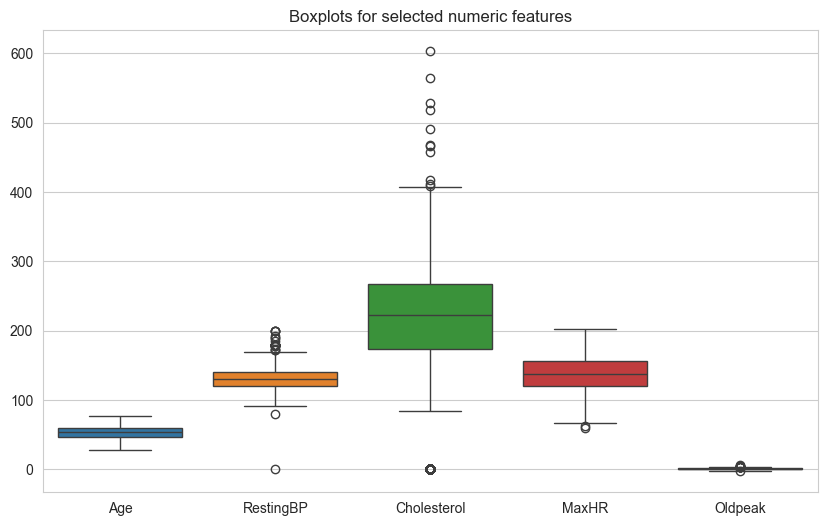

In [24]:
# 💻 কোড ১৬: Outlier Visualization

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# কিছু numeric column-এর boxplot
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_heart_encoded[numeric_cols])
plt.title("Boxplots for selected numeric features")
plt.show()

In [25]:
# 💻 কোড ১৭: IQR দিয়ে Outlier খোঁজা

# Cholesterol column-এ IQR method প্রয়োগ
col = "Cholesterol"
Q1 = df_heart_encoded[col].quantile(0.25)
Q3 = df_heart_encoded[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_heart_encoded[
    (df_heart_encoded[col] < lower) | (df_heart_encoded[col] > upper)
]
print(f"Number of detected outliers in {col}: ", len(outliers))

Number of detected outliers in Cholesterol:  183


In [26]:
#💻 কোড ১৮: Outlier Handle করার ৩ পদ্ধতি

# পদ্ধতি ১: Outlier বাদ দেওয়া (Remove)
df_no_outliers = df_heart_encoded[
    (df_heart_encoded[col] >= lower) & (df_heart_encoded[col] <= upper)
]

# পদ্ধতি ২: Outlier Cap করা (Winsorization)
df_capped = df_heart_encoded.copy()
df_capped[col] = df_capped[col].clip(lower, upper)

# পদ্ধতি ৩: Log Transform (skewed distribution-এর জন্য)
df_log = df_heart_encoded.copy()
df_log[col + "_log"] = np.log(df_log[col] + 1)

print(len(df_no_outliers))
print(df_capped)
print(df_log)

735
     Age  Sex  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
0     40    1        140        289.0          0    172               0   
1     49    0        160        180.0          0    156               0   
2     37    1        130        283.0          0     98               0   
3     48    0        138        214.0          0    108               1   
4     54    1        150        195.0          0    122               0   
..   ...  ...        ...          ...        ...    ...             ...   
913   45    1        110        264.0          0    132               0   
914   68    1        144        193.0          1    141               0   
915   57    1        130        131.0          0    115               1   
916   57    0        130        236.0          0    174               0   
917   38    1        138        175.0          0    173               0   

     Oldpeak  HeartDisease  ChestPainType_ASY  ChestPainType_ATA  \
0        0.0             0 

## 📌 5. Feature Transformation and Domain-Driven Features
### 🔸 বাস্তব উপমা: বিদ্যুৎ বিলের ক্যাটাগরি

মাসিক বিল: 2400, 2600, 2800, 3000, 9000, 2700। Raw সংখ্যায় pattern বোঝা কঠিন। LOW/MEDIUM/HIGH ক্যাটাগরিতে ভাগ করলে বোঝা সহজ।

In [27]:
# 💻 কোড ১৯: Polynomial Features

from sklearn.preprocessing import PolynomialFeatures

# Age এবং MaxHR থেকে polynomial features
poly_cols = ["Age", "MaxHR"]
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(df_heart_encoded[poly_cols])
poly_feature_names = poly.get_feature_names_out(poly_cols)

print(poly_feature_names)
print(poly_features.shape)

['Age' 'MaxHR' 'Age^2' 'Age MaxHR' 'MaxHR^2']
(918, 5)


In [29]:
# 💻 কোড ২০: Binning (Age Groups)
# Age কে categories তে ভাগ করা
df_heart_encoded["Age_bin"] = pd.cut(
    df_heart_encoded["Age"],
    bins=[0, 30, 50, 70, 100],
    labels=["Young", "Middle", "Middle Old", "Old"]
)
print(df_heart_encoded[["Age", "Age_bin"]].head(50))

    Age     Age_bin
0    40      Middle
1    49      Middle
2    37      Middle
3    48      Middle
4    54  Middle Old
5    39      Middle
6    45      Middle
7    54  Middle Old
8    37      Middle
9    48      Middle
10   37      Middle
11   58  Middle Old
12   39      Middle
13   49      Middle
14   42      Middle
15   54  Middle Old
16   38      Middle
17   43      Middle
18   60  Middle Old
19   36      Middle
20   43      Middle
21   44      Middle
22   49      Middle
23   44      Middle
24   40      Middle
25   36      Middle
26   53  Middle Old
27   52  Middle Old
28   53  Middle Old
29   51  Middle Old
30   53  Middle Old
31   56  Middle Old
32   54  Middle Old
33   41      Middle
34   43      Middle
35   32      Middle
36   65  Middle Old
37   41      Middle
38   48      Middle
39   48      Middle
40   54  Middle Old
41   54  Middle Old
42   35      Middle
43   52  Middle Old
44   43      Middle
45   59  Middle Old
46   37      Middle
47   50      Middle
48   36      Middle


In [30]:
# 💻 কোড ২১: Domain-Driven Features

# চিকিৎসা জ্ঞান থেকে নতুন features তৈরি

# Blood Pressure Risk
def bp_risk(bp):
    if bp < 120:
        return "Normal"
    elif bp < 140:
        return "Elevated"
    else:
        return "High"

# Oldpeak Risk (ST Depression)
def oldpeak_risk(op):
    if op == 0:
        return "No Stress"
    elif op < 2:
        return "Moderate Stress"
    else:
        return "High Stress"

df_heart_encoded["BP_Risk"] = df_heart_encoded["RestingBP"].apply(bp_risk)
df_heart_encoded["Oldpeak_Risk"] = df_heart_encoded["Oldpeak"].apply(oldpeak_risk)
df_heart_encoded[["RestingBP", "BP_Risk", "Oldpeak", "Oldpeak_Risk"]]


,RestingBP,BP_Risk,Oldpeak,Oldpeak_Risk
0,140,High,0.0,No Stress
1,160,High,1.0,Moderate Stress
2,130,Elevated,0.0,No Stress
3,138,Elevated,1.5,Moderate Stress
4,150,High,0.0,No Stress
...,...,...,...,...
913,110,Normal,1.2,Moderate Stress
914,144,High,3.4,High Stress
915,130,Elevated,1.2,Moderate Stress
916,130,Elevated,0.0,No Stress


### 📌 6. Full Preprocessing Pipeline
#### 🔸 বাস্তব উপমা: গার্মেন্টস ফ্যাক্টরির অ্যাসেম্বলি লাইন

কাটিং → সেলাই → প্রিন্টিং → আয়রন → প্যাকেজিং। প্রতিটি ধাপ সঠিক ক্রমে হতে হবে।

In [32]:
#💻 কোড ২২: Pipeline তৈরি

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric এবং Categorical columns সংজ্ঞায়িত করা
num_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_features = ["Sex", "ExerciseAngina", "ChestPainType", "RestingECG", "ST_Slope"]

# Numeric pipeline
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("ohe", OneHotEncoder(drop="first"))
])

# দুটো Pipeline একত্রিত করা
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# Full pipeline: preprocessing + model
clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

### 📌 7. Quick Sanity Check
🔸 বাস্তব উপমা: গাড়ি কেনার আগে টেস্ট ড্রাইভ

শুধু brochure দেখে গাড়ি কিনবে না — test drive করবে।

In [1]:
# 💻 কোড ২৩: Full Pipeline Train ও Test

from sklearn.metrics import accuracy_score

# Original df_heart ব্যবহার (encoded নয়)
X = df_heart.drop(columns=[target_col])
y = df_heart[target_col]

X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Full pipeline fit করা
clf.fit(X_train_pipe, y_train_pipe)

# Predict ও Evaluate
y_pred_pipe = clf.predict(X_test_pipe)
acc = accuracy_score(y_test_pipe, y_pred_pipe)
print("Logistic Regression with preprocessing pipeline: ", acc)

NameError: name 'df_heart' is not defined